In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from pathlib import Path
import datetime
import matplotlib.pyplot as plt

In [18]:
DATA_FOLDER = Path(os.path.abspath("")).parent.parent / "taxi_data" / "yellow_tripdata"
GENERIC_FILENAME = "yellow_tripdata_taxi_data_"

## Create a sorted dict with file dates

In [19]:
data_filenames = os.listdir(DATA_FOLDER)
filenames_dict = {"_".join(filename.split(".")[0].split("_")[4:]): filename for filename in data_filenames}

date_dict = {datetime.datetime(int(x.split("_")[0]), int(x.split("_")[1]), 1): x for x in list(filenames_dict.keys())}
sorted_date_dict = dict(sorted(date_dict.items(), key=lambda x: x[0]))

print(len(data_filenames))
COUNTER = len(data_filenames)

29


# EXECUTE BELOW TO LOAD ALL PARQUET FILES

In [20]:
df_main = pd.DataFrame()
for date in sorted_date_dict.values():
    filename = "".join([GENERIC_FILENAME, date, ".parquet"])
    filepath = Path.joinpath(DATA_FOLDER, filename)
    df = pd.read_parquet(filepath, dtype_backend="pyarrow")

    df_main = pd.concat([df_main, df])

# *****************************

# EXECUTE BELOW FOR ONLY THE LATEST FILE

In [12]:
df_main = pd.DataFrame()
filename = "".join([GENERIC_FILENAME, str(list(sorted_date_dict.values())[-1]), ".parquet"])
filepath = Path.joinpath(DATA_FOLDER, filename)
print(f"executing {str(filepath)}")
df_main = pd.read_parquet(filepath, dtype_backend="pyarrow")

executing C:\Users\lbistas\projects\ny-taxi-predictor\taxi_data\yellow_tripdata\yellow_tripdata_taxi_data_2026_5.parquet


# *****************************

In [21]:
# sanity check
print(df_main.shape)
print(df_main.memory_usage(deep=True).sum() / 1024 ** 2, "MiB")

(108891604, 20)
16535.30185317993 MiB


In [39]:
zero_distance = (df_main["trip_distance"] == 0) & (~df_main["trip_distance"].isna())
negative_distance = (df_main["trip_distance"] < 0) & (~df_main["trip_distance"].isna())
null_distance = df_main["trip_distance"].isna()

print(f"num of zero distance rows: {len(df_main[zero_distance])}\n"
      f"num of negative distance rows: {len(df_main[negative_distance])}\n"
      f"num of null distance rows: {len(df_main[null_distance])}")

num of zero distance rows: 2756007
num of negative distance rows: 0
num of null distance rows: 0


In [40]:
zero_passengers = (df_main["passenger_count"] == 0) & (~df_main["passenger_count"].isna())
negative_passengers = (df_main["passenger_count"] < 0) & (~df_main["passenger_count"].isna())
null_passengers = df_main["passenger_count"].isna()

print(f"num of zero passengers rows: {len(df_main[zero_passengers])}\n"
      f"num of negative passengers rows: {len(df_main[negative_passengers])}\n"
      f"num of null passengers rows: {len(df_main[null_passengers])}")

num of zero passengers rows: 726279
num of negative passengers rows: 0
num of null passengers rows: 20515406


In [41]:
invalid_vendor = (~df_main["VendorID"].isin([1, 2, 6, 7]) & (~df_main["VendorID"].isna()))
null_vendor = df_main["VendorID"].isna()

print(f"num of invalid vendor rows: {len(df_main[invalid_vendor])}\n"
      f"num of null vendor rows: {len(df_main[null_vendor])}")

num of invalid vendor rows: 0
num of null vendor rows: 0


In [42]:
invalid_ratecode = (~df_main["RatecodeID"].isin([1, 2, 3, 4, 5, 6, 99]) & (~df_main["RatecodeID"].isna()))
null_ratecode = df_main["RatecodeID"].isna()

print(f"num of invalid ratecode rows: {len(df_main[invalid_ratecode])}\n"
      f"num of null ratecode rows: {len(df_main[null_ratecode])}")

num of invalid ratecode rows: 0
num of null ratecode rows: 20515406


In [46]:
zero_dt = (df_main["tpep_pickup_datetime"] == df_main["tpep_dropoff_datetime"]) & (~df_main["tpep_pickup_datetime"].isna()) & (~df_main["tpep_dropoff_datetime"].isna())
negative_dt = (df_main["tpep_pickup_datetime"] > df_main["tpep_dropoff_datetime"]) & (~df_main["tpep_pickup_datetime"].isna()) & (~df_main["tpep_dropoff_datetime"].isna())
null_dt = df_main["tpep_pickup_datetime"].isna() | df_main["tpep_dropoff_datetime"].isna()

print(f"num of zero dt rows: {len(df_main[zero_dt])}\n"
      f"num of negative dt rows: {len(df_main[negative_dt])}\n"
      f"num of null dt rows: {len(df_main[null_dt])}")

num of zero dt rows: 792374
num of negative dt rows: 3815
num of null dt rows: 0


In [44]:
zero_fare_amount = (df_main["fare_amount"] == 0) & (~df_main["fare_amount"].isna())
negative_fare_amount = (df_main["fare_amount"] < 0) & (~df_main["fare_amount"].isna())
null_fare_amount = df_main["fare_amount"].isna()

print(f"num of zero fare amount rows: {len(df_main[zero_fare_amount])}\n"
      f"num of negative fare amount rows: {len(df_main[negative_fare_amount])}\n"
      f"num of null fare amount rows: {len(df_main[null_fare_amount])}")

num of zero fare amount rows: 52183
num of negative fare amount rows: 3695111
num of null fare amount rows: 0


In [49]:
df_main[zero_dt].head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
23,1,2024-01-01 00:14:29,2024-01-01 00:14:29,1,0.0,1,N,236,264,2,3.0,3.5,0.5,0.0,0.0,1.0,8.0,2.5,0.0,<NA>
16790,1,2024-01-01 02:47:57,2024-01-01 02:47:57,1,0.0,1,N,61,61,1,52.5,0.0,0.5,0.0,0.0,1.0,54.0,0.0,0.0,<NA>
17277,1,2024-01-01 03:18:03,2024-01-01 03:18:03,1,0.0,1,N,246,264,2,33.99,0.0,0.0,0.0,0.0,0.0,33.99,0.0,0.0,<NA>
19195,1,2024-01-01 03:06:02,2024-01-01 03:06:02,1,0.0,1,Y,113,264,2,35.22,0.0,0.0,0.0,0.0,0.0,35.22,0.0,0.0,<NA>
21393,1,2024-01-01 04:08:24,2024-01-01 04:08:24,2,0.0,1,N,249,264,2,10.7,3.5,0.5,0.0,0.0,1.0,15.7,2.5,0.0,<NA>
22868,1,2024-01-01 04:06:44,2024-01-01 04:06:44,1,0.0,1,N,137,264,2,14.51,0.0,0.0,0.0,0.0,0.0,14.51,0.0,0.0,<NA>
23585,1,2024-01-01 05:21:13,2024-01-01 05:21:13,1,0.0,5,Y,48,264,2,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,<NA>
25800,1,2024-01-01 07:33:54,2024-01-01 07:33:54,0,0.0,99,Y,223,264,1,66.7,0.0,0.0,0.0,0.0,0.0,66.7,0.0,0.0,<NA>
25801,1,2024-01-01 07:40:28,2024-01-01 07:40:28,0,0.0,99,Y,223,264,1,46.0,0.0,0.0,0.0,0.0,0.0,46.0,0.0,0.0,<NA>
28009,1,2024-01-01 09:24:09,2024-01-01 09:24:09,1,0.0,1,Y,238,264,2,3.0,2.5,0.5,0.0,0.0,1.0,7.0,2.5,0.0,<NA>


In [16]:
df_main[df_main["passenger_count"].isna()].head(10)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
3135465,2,2026-05-01 00:01:15,2026-05-01 00:38:46,<NA>,7.39,<NA>,<NA>,161,181,0,42.72,0.0,0.5,0.0,0.0,1.0,52.12,<NA>,<NA>,0.75
3135466,2,2026-05-01 00:13:00,2026-05-01 00:37:00,<NA>,4.45,<NA>,<NA>,249,236,0,30.25,0.0,0.5,0.0,0.0,1.0,39.2,<NA>,<NA>,0.75
3135467,2,2026-05-01 00:06:24,2026-05-01 00:40:09,<NA>,8.13,<NA>,<NA>,148,166,0,50.21,0.0,0.5,0.0,0.0,1.0,60.45,<NA>,<NA>,0.75
3135468,1,2026-05-01 00:01:38,2026-05-01 00:21:59,<NA>,6.5,<NA>,<NA>,236,243,0,25.3,0.0,0.5,0.0,0.0,1.0,39.35,<NA>,<NA>,0.0
3135469,1,2026-05-01 00:00:35,2026-05-01 00:25:01,<NA>,2.7,<NA>,<NA>,231,68,0,21.65,0.0,0.5,0.0,0.0,1.0,26.4,<NA>,<NA>,0.75
3135470,2,2026-05-01 00:02:55,2026-05-01 00:17:04,<NA>,2.46,<NA>,<NA>,113,233,0,19.2,0.0,0.5,0.0,0.0,1.0,23.95,<NA>,<NA>,0.75
3135471,2,2026-05-01 00:21:28,2026-05-01 00:36:17,<NA>,2.3,<NA>,<NA>,229,50,0,20.19,0.0,0.5,0.0,0.0,1.0,24.94,<NA>,<NA>,0.75
3135472,1,2026-05-01 00:24:26,2026-05-01 00:35:01,<NA>,1.9,<NA>,<NA>,142,238,0,10.11,0.0,0.5,0.0,0.0,1.0,15.95,<NA>,<NA>,0.0
3135473,2,2026-05-01 00:31:17,2026-05-01 00:44:30,<NA>,1.4,<NA>,<NA>,148,79,0,9.95,0.0,0.5,0.0,0.0,1.0,14.7,<NA>,<NA>,0.75
3135474,2,2026-05-01 00:32:38,2026-05-01 00:42:02,<NA>,3.68,<NA>,<NA>,64,101,0,16.64,0.0,0.5,0.0,0.0,1.0,18.14,<NA>,<NA>,0.0


In [15]:
df_main.info()

invalid_condition = zero_distance | zero_passengers | invalid_vendor | invalid_ratecode | zero_dt | invalid_fare_amount

print(150*"*")
df_invalid = df_main.loc[invalid_condition]
print(f"{len(df_invalid)} invalid trips")

df_valid = df_main.loc[~invalid_condition]
print(f"{len(df_valid)} valid rows")

<class 'pandas.DataFrame'>
RangeIndex: 4090836 entries, 0 to 4090835
Data columns (total 20 columns):
 #   Column                 Dtype                 
---  ------                 -----                 
 0   VendorID               int32[pyarrow]        
 1   tpep_pickup_datetime   timestamp[us][pyarrow]
 2   tpep_dropoff_datetime  timestamp[us][pyarrow]
 3   passenger_count        int64[pyarrow]        
 4   trip_distance          double[pyarrow]       
 5   RatecodeID             int64[pyarrow]        
 6   store_and_fwd_flag     large_string[pyarrow] 
 7   PULocationID           int32[pyarrow]        
 8   DOLocationID           int32[pyarrow]        
 9   payment_type           int64[pyarrow]        
 10  fare_amount            double[pyarrow]       
 11  extra                  double[pyarrow]       
 12  mta_tax                double[pyarrow]       
 13  tip_amount             double[pyarrow]       
 14  tolls_amount           double[pyarrow]       
 15  improvement_surcharge  dou

### BASIC PLOTS

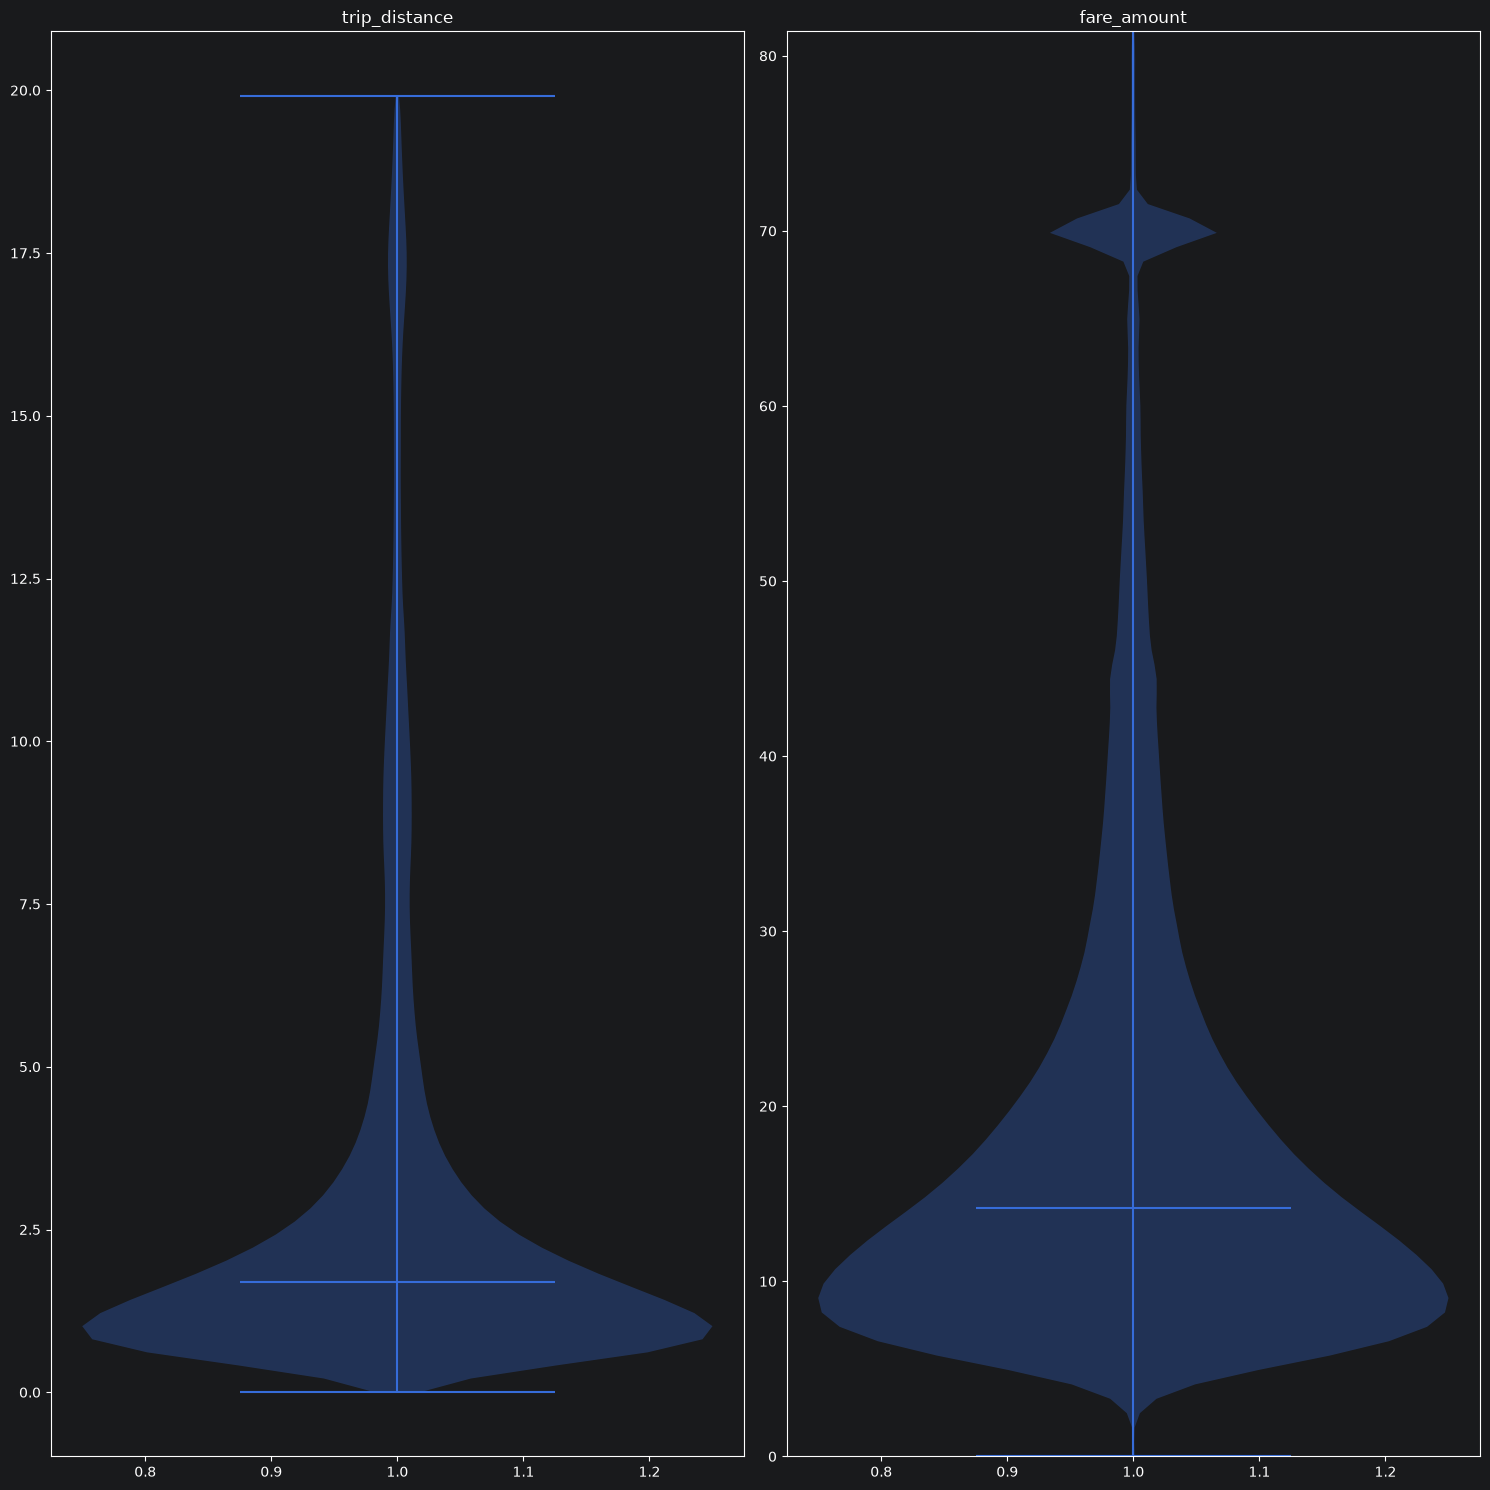

In [39]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 15))

for ax, column in zip(axs, ["trip_distance", "fare_amount"]):
    values = df_valid[column]
    values = values[values <= values.quantile(0.99)]

    ax.violinplot(values, showmedians=True)
    ax.set_title(column)
    plt.ylim(float(values.min()), float(values.max()))

plt.tight_layout()
plt.show()